In [1]:
import os, glob, re
import numpy as np
import pandas as pd

BASE_DIR = r"../../data/Riot_API/processed/match_detail"

META_GLOB = os.path.join(BASE_DIR, "**", "*meta*.parquet")
TEAM_GLOB = os.path.join(BASE_DIR, "**", "*team*.parquet")
PART_GLOB = os.path.join(BASE_DIR, "**", "*participant*.parquet")

# -----------------------
# Patch 범위 필터 (15.1.* ~ 16.2.*)
# -----------------------
def parse_major_minor(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return (None, None)
    s = str(v).strip()
    m = re.match(r"^\s*(\d+)\.(\d+)", s)
    if not m:
        return (None, None)
    return int(m.group(1)), int(m.group(2))

def in_range_15_1_to_16_2(v):
    maj, minor = parse_major_minor(v)
    if maj is None:
        return False
    return (maj > 15 or (maj == 15 and minor >= 1)) and (maj < 16 or (maj == 16 and minor <= 2))

# -----------------------
# Risk metrics
# -----------------------
def risk_metrics(s, extreme_thr_z=2.0, eps=1e-9):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan,
                "q10": np.nan, "q90": np.nan, "q90_q10_spread": np.nan,
                "extreme_rate": np.nan,
                "cv": np.nan, "spread_over_median": np.nan}

    mean = s.mean()
    std = s.std(ddof=1)
    q10 = s.quantile(0.10)
    q90 = s.quantile(0.90)
    med = s.median()
    spread = q90 - q10

    # extreme_rate: z-score 기반 (기존 로직 유지했다면 그대로)
    z = (s - mean) / (std + eps)
    extreme_rate = (np.abs(z) >= extreme_thr_z).mean()

    # ✅ 단위 제거 지표
    cv = std / (abs(mean) + eps)
    spread_over_median = spread / (abs(med) + eps)

    return {
        "n": int(len(s)),
        "mean": float(mean),
        "std": float(std),
        "q10": float(q10),
        "q90": float(q90),
        "q90_q10_spread": float(spread),
        "extreme_rate": float(extreme_rate),
        "cv": float(cv),
        "spread_over_median": float(spread_over_median),
    }

def summarize_by_group(df, group_cols, value_cols, label=None):
    rows = []
    for g, sub in df.groupby(group_cols, dropna=False):
        if not isinstance(g, tuple):
            g = (g,)
        base = dict(zip(group_cols, g))
        for col in value_cols:
            m = risk_metrics(sub[col])
            row = {**base, "metric": col, **m}
            if label is not None:
                row["label"] = label
            rows.append(row)
    out = pd.DataFrame(rows)
    return out.sort_values(group_cols + ["metric"]).reset_index(drop=True)

def summarize_overall(df, value_cols, label="OVERALL"):
    rows = []
    for col in value_cols:
        m = risk_metrics(df[col])
        rows.append({"group": label, "metric": col, **m})
    out = pd.DataFrame(rows)
    return out.sort_values("metric").reset_index(drop=True)

In [2]:
import matplotlib.pyplot as plt

# 노트북 시각화 기본 설정
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

def plot_top_bar(df, value_col, title, top_n=10, label_col=None, group_cols=None):
    """
    df: summarize_by_group 결과 테이블
    value_col: 'std' or 'q90_q10_spread' or 'extreme_rate'
    label_col: 지정하면 해당 컬럼을 x축 라벨로 사용
    group_cols: label_col이 없을 때 라벨에 포함할 그룹 컬럼들(예: ["platform"], ["platform","win"])
    """
    x = df.copy().sort_values(value_col, ascending=False).head(top_n).copy()

    # 1) label_col이 지정된 경우
    if label_col is not None and label_col in x.columns:
        labels = x[label_col].astype(str).tolist()

    else:
        # 2) 자동 라벨 생성: group_cols + metric
        if group_cols is None:
            # 흔히 쓰는 그룹 컬럼 자동 탐지
            candidates = ["platform", "team_position", "win", "queue_id", "tier"]
            group_cols = [c for c in candidates if c in x.columns]

        parts = []
        for c in group_cols:
            parts.append(x[c].astype(str))

        # metric은 항상 붙이기
        if "metric" in x.columns:
            parts.append(x["metric"].astype(str))
        else:
            parts.append(pd.Series(["metric?"] * len(x)))

        label_series = parts[0]
        for s in parts[1:]:
            label_series = label_series + " | " + s

        labels = label_series.tolist()

    plt.figure()
    plt.bar(range(len(x)), x[value_col].values)
    plt.xticks(range(len(x)), labels, rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_grouped_metric(df, group_col, metric_col, value_col, title, order=None):
    """
    group_col: platform / team_position 등
    metric_col: metric(변수명)
    value_col: std / q90_q10_spread / extreme_rate
    """
    x = df.copy()
    if order is not None:
        x[group_col] = pd.Categorical(x[group_col], categories=order, ordered=True)
        x = x.sort_values(group_col)

    pivot = x.pivot_table(index=group_col, columns=metric_col, values=value_col, aggfunc="mean")
    plt.figure(figsize=(12, 5))
    for m in pivot.columns:
        plt.plot(pivot.index.astype(str), pivot[m].values, marker="o", label=m)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(value_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_headline(title, lines):
    print("\n" + "="*80)
    print(title)
    print("="*80)
    for s in lines:
        print(" -", s)

In [3]:
meta_paths = sorted(glob.glob(META_GLOB, recursive=True))
print("meta files:", len(meta_paths))
assert meta_paths, "No meta parquet found."

meta_cols = ["match_id", "platform", "queue_id", "game_duration", "game_version", "end_of_game_result"]
meta = pd.concat([pd.read_parquet(p, columns=[c for c in meta_cols if c in pd.read_parquet(p).columns]) for p in meta_paths],
                 ignore_index=True)

print("meta raw:", meta.shape)
# 1) end_of_game_result == GameComplete
meta["end_of_game_result"] = meta["end_of_game_result"].astype(str).str.strip()
meta = meta.loc[meta["end_of_game_result"].eq("GameComplete")].copy()

# 2) match_id 중복 제거
meta = meta.drop_duplicates(subset=["match_id"], keep="first").copy()

# 3) game_duration >= 900
meta["game_duration"] = pd.to_numeric(meta["game_duration"], errors="coerce")
meta = meta.loc[meta["game_duration"].ge(900)].copy()

# 4) game_version 15.1~16.2
meta = meta.loc[meta["game_version"].map(in_range_15_1_to_16_2)].copy()

print("meta filtered:", meta.shape)
valid_match_ids = set(meta["match_id"].dropna().unique())
print("valid_match_ids:", len(valid_match_ids))

meta files: 16
meta raw: (113978, 6)
meta filtered: (79637, 6)
valid_match_ids: 79637


In [4]:
team_paths = sorted(glob.glob(TEAM_GLOB, recursive=True))
print("team files:", len(team_paths))
assert team_paths, "No teams parquet found."

team_use_cols = ["match_id", "platform", "queue_id", "team_id", "win", "game_version", "game_duration"]
teams = pd.concat([pd.read_parquet(p, columns=team_use_cols) for p in team_paths], ignore_index=True)

print("teams raw:", teams.shape)

# meta 필터 적용 (match_id 기준)
teams = teams.loc[teams["match_id"].isin(valid_match_ids)].copy()

# 중복 제거 (안전)
teams = teams.drop_duplicates(subset=["match_id", "team_id"], keep="first").copy()

# 타입 정리
teams["win"] = teams["win"].astype(str).str.lower().map({"true": 1, "false": 0}).fillna(teams["win"])
teams["win"] = pd.to_numeric(teams["win"], errors="coerce")

print("teams filtered:", teams.shape)
teams.head()

team files: 16
teams raw: (227900, 7)
teams filtered: (159274, 7)


,match_id,platform,queue_id,team_id,win,game_version,game_duration
2,BR1_3200309821,br1,420,100,0,16.2.741.3171,914
3,BR1_3200309821,br1,420,200,1,16.2.741.3171,914
4,BR1_3188135821,br1,420,100,0,15.24.734.7485,1195
5,BR1_3188135821,br1,420,200,1,15.24.734.7485,1195
6,BR1_3078921650,br1,420,100,0,15.6.667.3303,2618


In [5]:
part_paths = sorted(glob.glob(PART_GLOB, recursive=True))
print("participant files:", len(part_paths))
assert part_paths, "No participants parquet found."

# 팀/포지션 분산 둘 다 쓰는 최소 컬럼
part_use_cols = [
    "match_id","platform","queue_id","team_id","participant_id",
    "team_position",
    "gold_earned","kills","deaths","assists",
    "total_damage_dealt_to_champions","vision_score"
]

parts = pd.concat([pd.read_parquet(p, columns=part_use_cols) for p in part_paths], ignore_index=True)
print("participants raw:", parts.shape)

# meta 필터 적용
parts = parts.loc[parts["match_id"].isin(valid_match_ids)].copy()

# 숫자형 변환
num_cols = ["gold_earned","kills","deaths","assists","total_damage_dealt_to_champions","vision_score"]
for c in num_cols:
    parts[c] = pd.to_numeric(parts[c], errors="coerce")

# 결측 0 대체 (합산용) - 필요하면 범위 조정 가능
for c in ["gold_earned","kills","deaths","assists","total_damage_dealt_to_champions","vision_score"]:
    parts[c] = parts[c].fillna(0)

print("participants filtered:", parts.shape)
parts.head()

team_totals = (
    parts.groupby(["match_id","platform","queue_id","team_id"], as_index=False)
         .agg(
             team_gold=("gold_earned","sum"),
             team_kills=("kills","sum"),
             team_deaths=("deaths","sum"),
             team_assists=("assists","sum"),
             team_dmg_to_champions=("total_damage_dealt_to_champions","sum"),
             team_vision=("vision_score","sum"),
             n_participants=("participant_id","nunique")
         )
)

print("team_totals:", team_totals.shape)
team_totals["n_participants"].value_counts().head(10)

participant files: 16
participants raw: (1139500, 12)
participants filtered: (796440, 12)
team_totals: (159274, 11)


n_participants
5    159274
Name: count, dtype: int64

In [6]:
team_df = teams.merge(team_totals, on=["match_id","platform","queue_id","team_id"], how="left")

# 포지션/AFK 등으로 10명 미완성 match가 섞일 수 있음: 팀 인원수 5 미만이면 제외 (권장)
team_df = team_df.loc[team_df["n_participants"].eq(5)].copy()

print("team_df:", team_df.shape)
print(team_df[["win","n_participants"]].value_counts(dropna=False).head(10))

TEAM_VALUE_COLS = ["team_gold","team_kills","team_deaths","team_dmg_to_champions","team_vision"]

# 전체 플랫폼 통합
team_risk_overall = summarize_overall(team_df, TEAM_VALUE_COLS, label="ALL_PLATFORMS")
display(team_risk_overall)

# 승/패 리스크 비교
team_risk_winloss = summarize_by_group(team_df, ["win"], TEAM_VALUE_COLS, label="WINLOSS")
display(team_risk_winloss)

# 서버별 승/패 리스크
team_risk_platform_winloss = summarize_by_group(team_df, ["platform","win"], TEAM_VALUE_COLS, label="PLATFORM_WINLOSS")
display(team_risk_platform_winloss.head(40))

team_df: (159274, 14)
win  n_participants
0    5                 79637
1    5                 79637
Name: count, dtype: int64


,group,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median
0,ALL_PLATFORMS,team_deaths,159274,32.358703,13.130942,15.0,49.0,34.0,0.039247,0.405793,1.030303
1,ALL_PLATFORMS,team_dmg_to_champions,159274,113890.966699,48082.533879,54816.6,175595.0,120778.4,0.038261,0.422180,1.102154
2,ALL_PLATFORMS,team_gold,159274,59937.103017,15968.105060,38696.0,79850.7,41154.7,0.051421,0.266414,0.682862
3,ALL_PLATFORMS,team_kills,159274,32.246067,13.125759,15.0,49.0,34.0,0.034111,0.407050,1.062500
4,ALL_PLATFORMS,team_vision,159274,141.933574,53.856381,75.0,213.0,138.0,0.039617,0.379448,1.000000


,win,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
0,0,team_deaths,79637,38.784447,10.625493,25.0,52.0,27.0,0.045770,0.273963,0.692308,WINLOSS
1,0,team_dmg_to_champions,79637,103907.306980,47616.863321,47761.0,166772.0,119011.0,0.041237,0.458263,1.224380,WINLOSS
2,0,team_gold,79637,55619.304143,15972.879603,34970.6,76241.4,41270.8,0.048357,0.287182,0.752321,WINLOSS
3,0,team_kills,79637,25.801876,12.206512,11.0,42.0,31.0,0.036604,0.473086,1.240000,WINLOSS
4,0,team_vision,79637,136.899393,54.127579,70.0,208.0,138.0,0.038663,0.395382,1.045455,WINLOSS
5,1,team_deaths,79637,25.932958,12.221413,11.0,42.0,31.0,0.037219,0.471270,1.240000,WINLOSS
6,1,team_dmg_to_champions,79637,123874.626417,46445.387942,66816.2,182404.4,115588.2,0.040044,0.374939,0.964642,WINLOSS
7,1,team_gold,79637,64254.901892,14749.367274,44775.8,82316.4,37540.6,0.068423,0.229545,0.583246,WINLOSS
8,1,team_kills,79637,38.690257,10.607454,25.0,52.0,27.0,0.050090,0.274163,0.710526,WINLOSS
9,1,team_vision,79637,146.967754,53.109083,81.0,216.0,135.0,0.039642,0.361366,0.944056,WINLOSS


,platform,win,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
0,br1,0,team_deaths,6457,39.078365,10.596552,25.0,53.0,28.0,0.043209,0.271162,0.717949,PLATFORM_WINLOSS
1,br1,0,team_dmg_to_champions,6457,102918.215890,46679.470526,46612.6,165800.2,119187.6,0.040421,0.453559,1.232346,PLATFORM_WINLOSS
2,br1,0,team_gold,6457,55696.641165,16143.376817,34479.0,76611.6,42132.6,0.045532,0.289845,0.767666,PLATFORM_WINLOSS
3,br1,0,team_kills,6457,26.270559,12.184458,11.0,43.0,32.0,0.036549,0.463807,1.280000,PLATFORM_WINLOSS
4,br1,0,team_vision,6457,136.947189,53.678845,71.6,208.0,136.4,0.039957,0.391967,1.033333,PLATFORM_WINLOSS
5,br1,1,team_deaths,6457,26.404987,12.197085,11.0,43.0,32.0,0.039182,0.461924,1.280000,PLATFORM_WINLOSS
6,br1,1,team_dmg_to_champions,6457,122677.889267,45812.741163,64876.6,180236.8,115360.2,0.041505,0.373439,0.968616,PLATFORM_WINLOSS
7,br1,1,team_gold,6457,64271.322905,14951.108441,44205.8,82865.0,38659.2,0.067678,0.232625,0.600000,PLATFORM_WINLOSS
8,br1,1,team_kills,6457,38.986681,10.586099,25.0,53.0,28.0,0.042899,0.271531,0.717949,PLATFORM_WINLOSS
9,br1,1,team_vision,6457,146.574106,52.528470,81.0,216.0,135.0,0.038873,0.358375,0.944056,PLATFORM_WINLOSS



TEAM volatility (OVERALL) - scale-free
 - 단위 문제 제거: CV(std/mean), Spread/Median((q90-q10)/median)로 리스크 비교


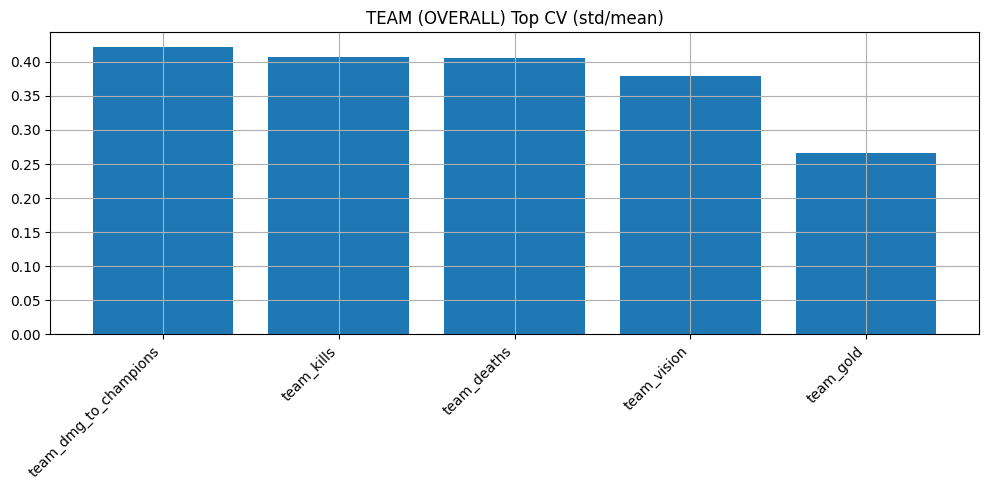

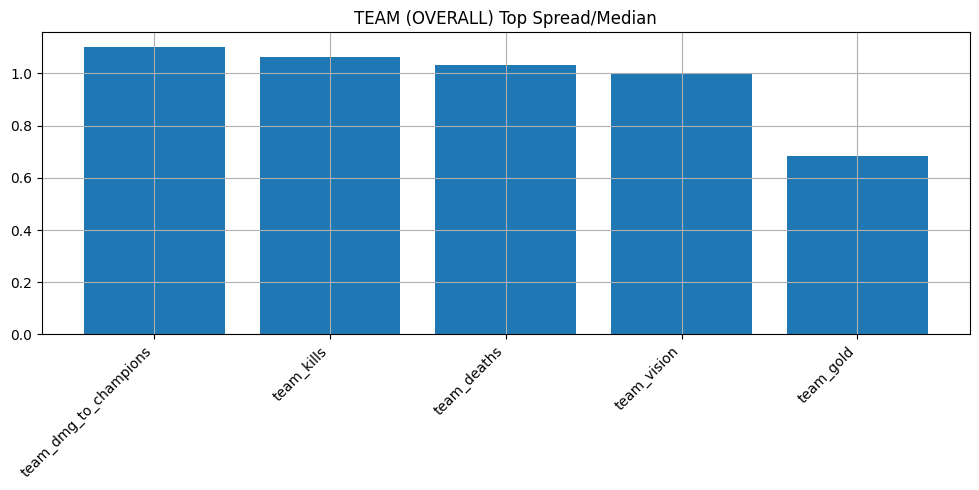

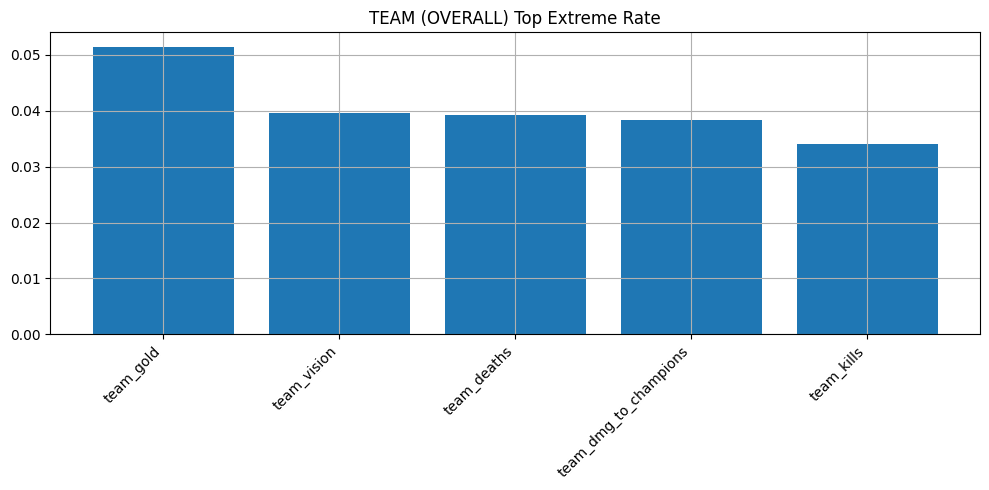

In [7]:
print_headline("TEAM volatility (OVERALL) - scale-free", [
    "단위 문제 제거: CV(std/mean), Spread/Median((q90-q10)/median)로 리스크 비교"
])

plot_top_bar(team_risk_overall, "cv", "TEAM (OVERALL) Top CV (std/mean)", top_n=10, group_cols=[])
plot_top_bar(team_risk_overall, "spread_over_median", "TEAM (OVERALL) Top Spread/Median", top_n=10, group_cols=[])
plot_top_bar(team_risk_overall, "extreme_rate", "TEAM (OVERALL) Top Extreme Rate", top_n=10, group_cols=[])

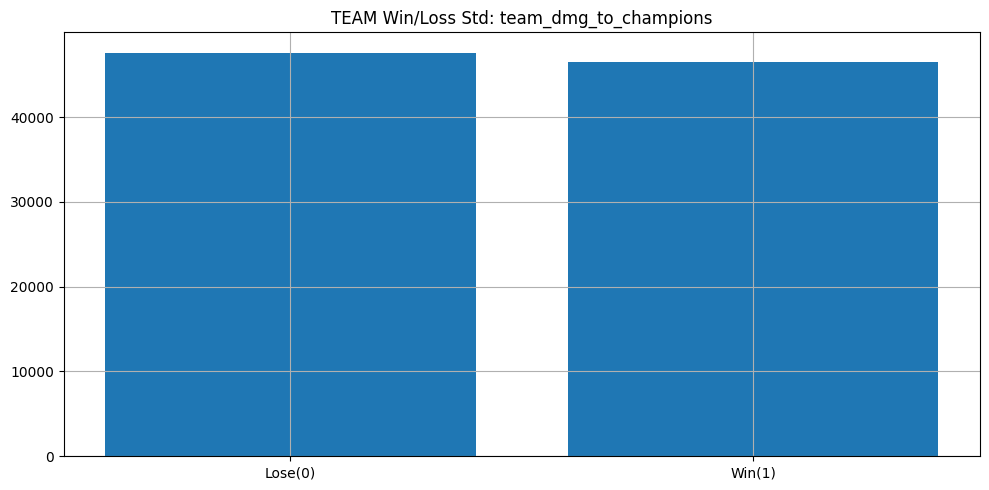

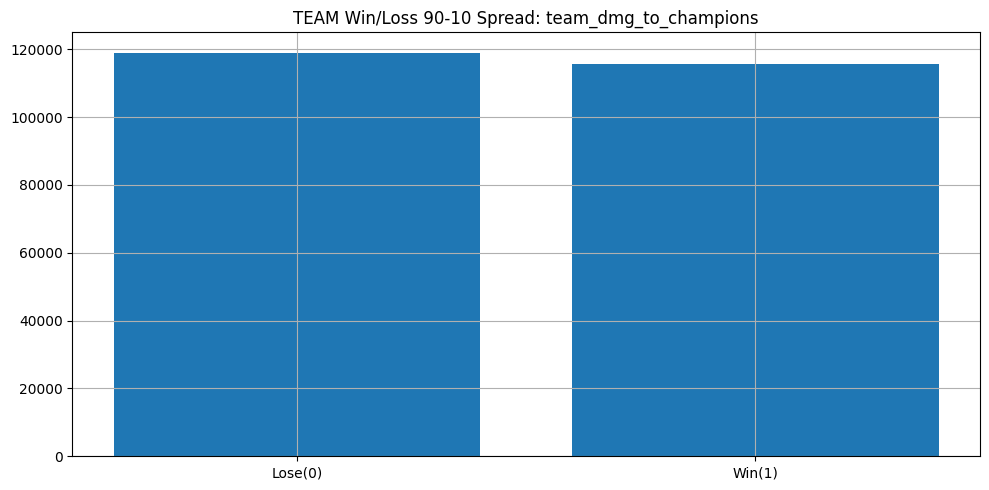

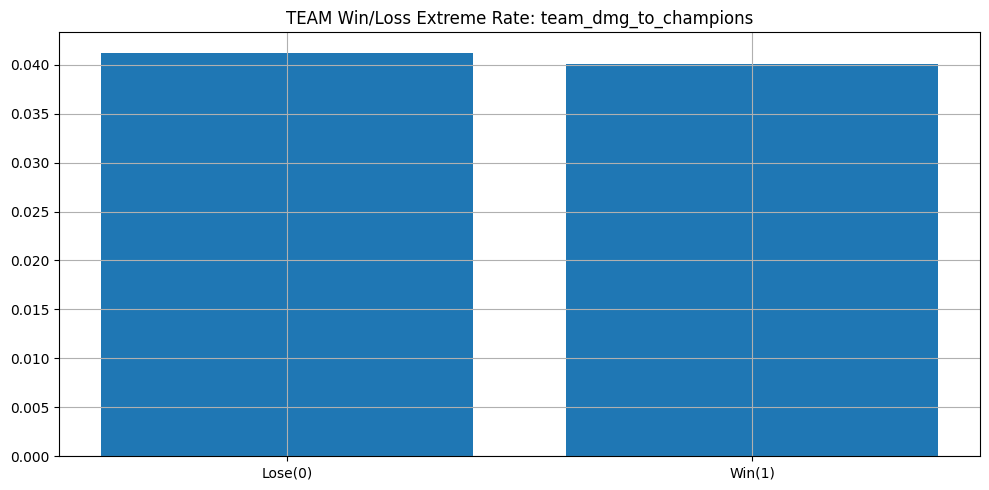

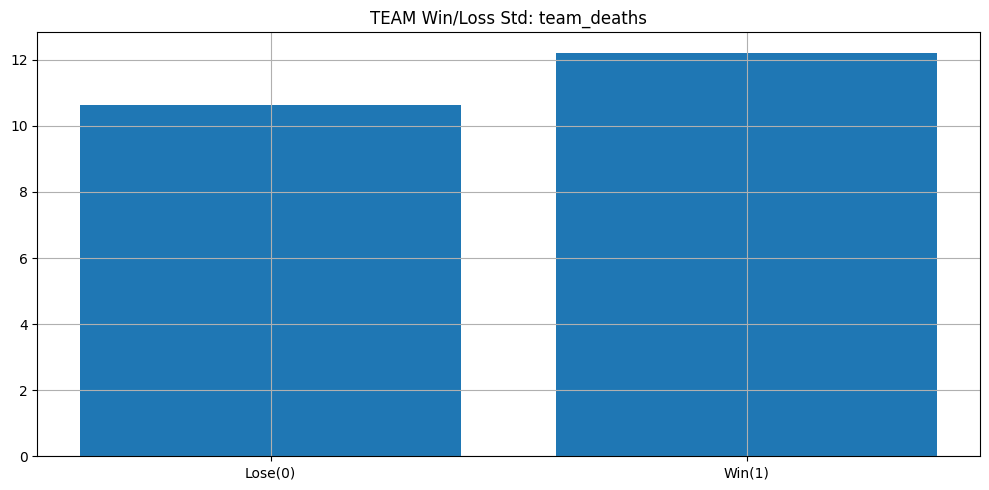

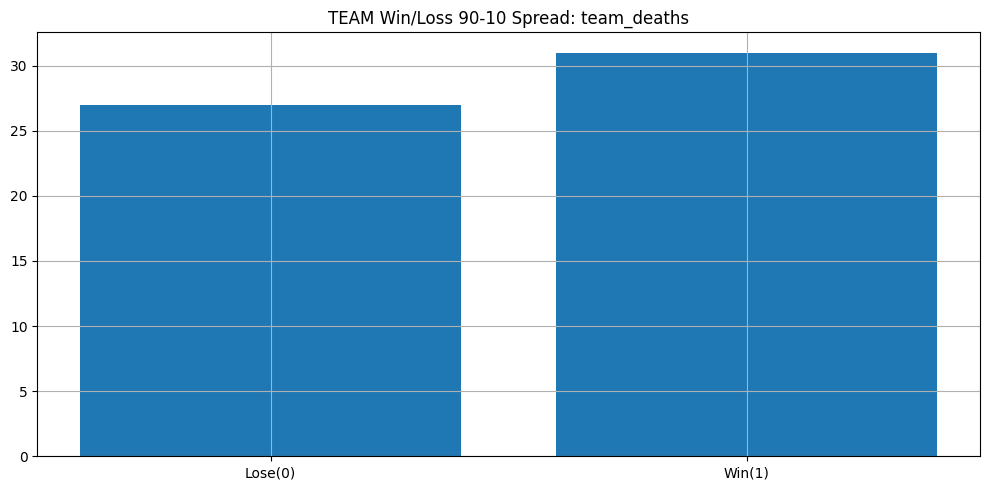

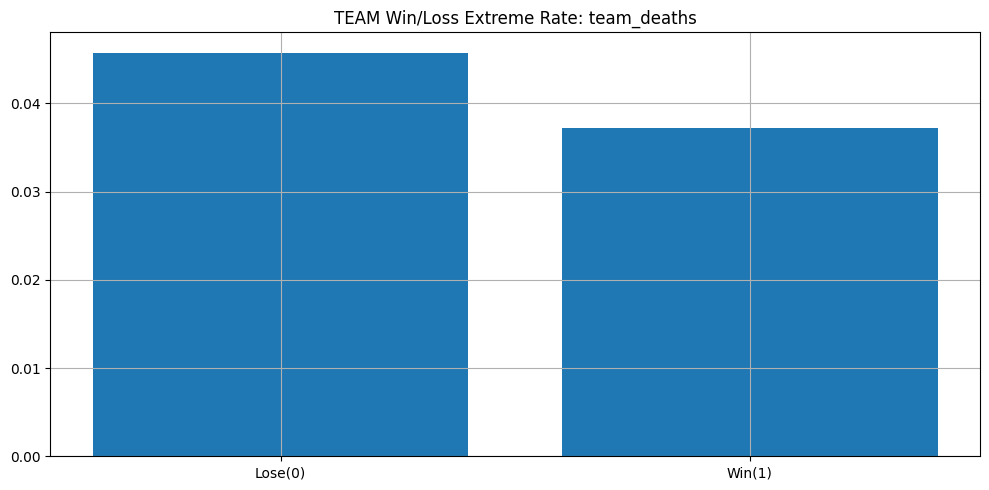

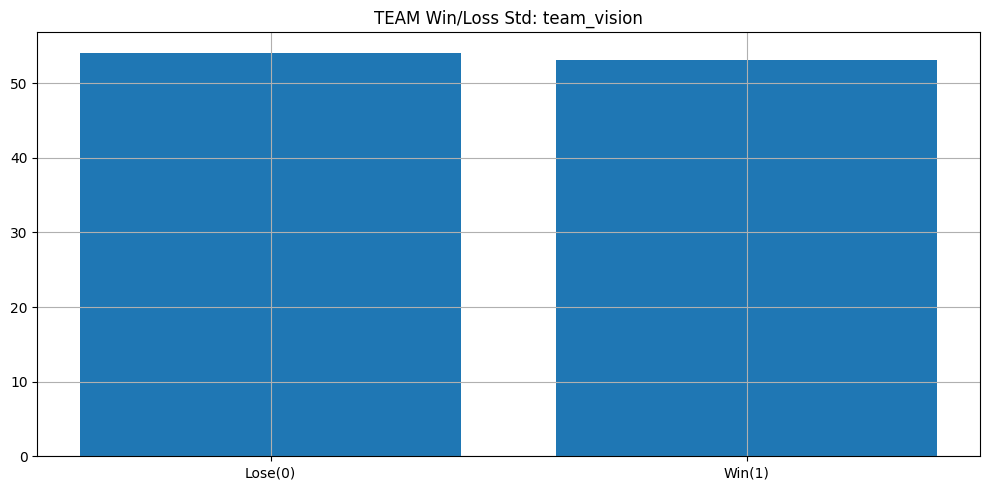

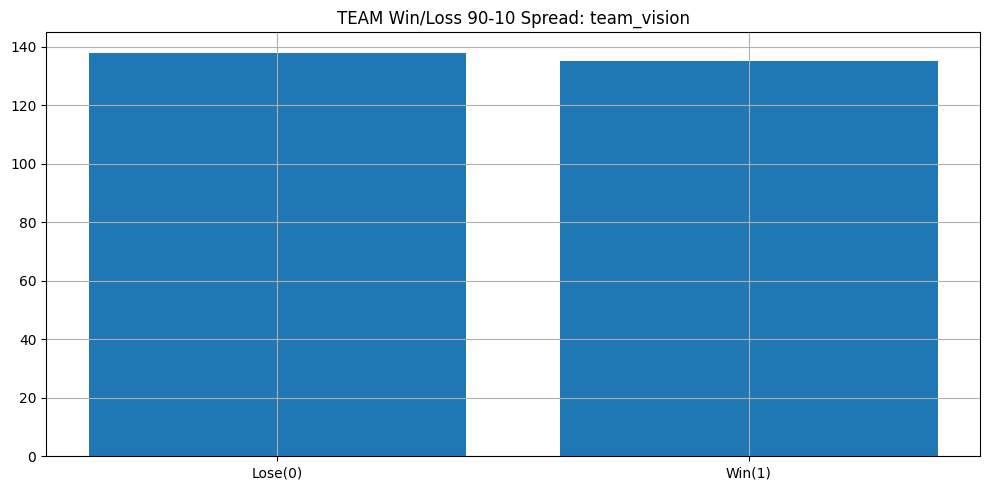

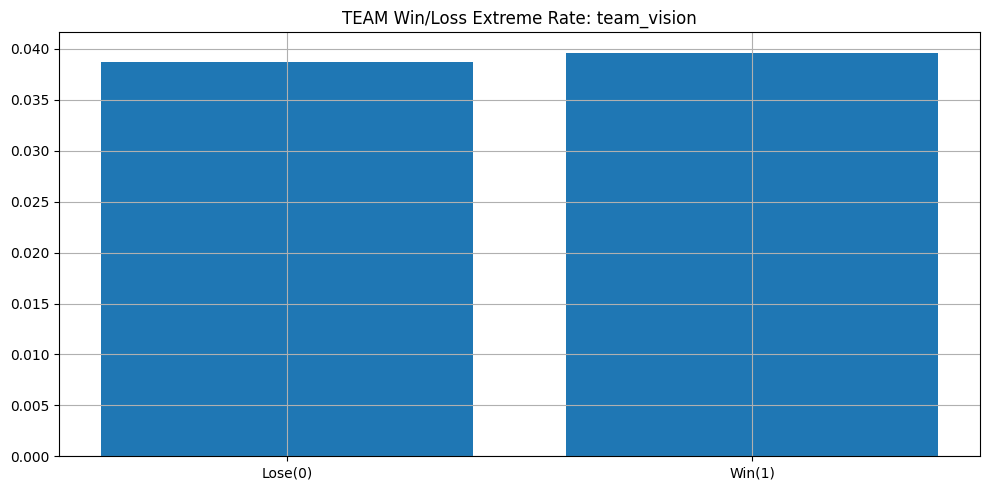

In [8]:
# 승/패 비교 (표준편차/스프레드/극단)

def plot_winloss_compare(risk_winloss_df, metric_name, value_col, title):
    x = risk_winloss_df[risk_winloss_df["metric"].eq(metric_name)].copy()
    x = x.sort_values("win").copy()  # 0,1
    labels = ["Lose(0)", "Win(1)"]
    vals = x[value_col].values
    plt.figure()
    plt.bar(labels, vals)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 비교할 핵심 metric 3개만 추천
for m in ["team_dmg_to_champions", "team_deaths", "team_vision"]:
    plot_winloss_compare(team_risk_winloss, m, "std", f"TEAM Win/Loss Std: {m}")
    plot_winloss_compare(team_risk_winloss, m, "q90_q10_spread", f"TEAM Win/Loss 90-10 Spread: {m}")
    plot_winloss_compare(team_risk_winloss, m, "extreme_rate", f"TEAM Win/Loss Extreme Rate: {m}")

In [9]:
# 포지션 정리: 빈값/UNKNOWN 제외
pos = parts.copy()
pos["team_position"] = pos["team_position"].astype(str).str.strip()
pos = pos.loc[pos["team_position"].isin(["TOP","JUNGLE","MIDDLE","BOTTOM","UTILITY"])].copy()

POS_VALUE_COLS = [
    "gold_earned",
    "kills",
    "deaths",
    "total_damage_dealt_to_champions",
    "vision_score",
]

# 5-1) 포지션별 리스크 (전체)
pos_risk_all = summarize_by_group(pos, ["team_position"], POS_VALUE_COLS, label="POS_ALL")
display(pos_risk_all)

# 5-2) 포지션별 승/패 리스크 (개인 단위에서 win 포함)
# participants 테이블에 win이 없으면 teams에서 merge 해야 함.
# 만약 parts에 win이 없다면 아래처럼:
if "win" not in pos.columns:
    pos = pos.merge(teams[["match_id","platform","queue_id","team_id","win"]], on=["match_id","platform","queue_id","team_id"], how="left")

pos_risk_pos_winloss = summarize_by_group(pos, ["team_position","win"], POS_VALUE_COLS, label="POS_WINLOSS")
display(pos_risk_pos_winloss.head(40))

,team_position,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
0,BOTTOM,deaths,159264,6.583616,3.393704,2.0,11.0,9.0,0.030019,0.515477,1.500000,POS_ALL
1,BOTTOM,gold_earned,159264,13200.217262,4195.552331,7975.0,18652.0,10677.0,0.043682,0.317840,0.825499,POS_ALL
2,BOTTOM,kills,159264,8.104098,5.443572,2.0,16.0,14.0,0.049490,0.671706,2.000000,POS_ALL
3,BOTTOM,total_damage_dealt_to_champions,159264,25783.063492,14512.324708,9994.0,44853.7,34859.7,0.044373,0.562863,1.513008,POS_ALL
4,BOTTOM,vision_score,159264,18.206877,9.286750,8.0,30.0,22.0,0.042678,0.510068,1.294118,POS_ALL
5,JUNGLE,deaths,159268,6.329181,3.442328,2.0,11.0,9.0,0.025197,0.543882,1.500000,POS_ALL
6,JUNGLE,gold_earned,159268,12755.048453,3812.171628,7926.0,17696.0,9770.0,0.044328,0.298876,0.777062,POS_ALL
7,JUNGLE,kills,159268,7.538401,4.880579,2.0,14.0,12.0,0.041283,0.647429,1.714286,POS_ALL
8,JUNGLE,total_damage_dealt_to_champions,159268,21462.775868,12249.674924,8072.0,37369.3,29297.3,0.043411,0.570740,1.520121,POS_ALL
9,JUNGLE,vision_score,159268,24.647029,11.582455,12.0,39.0,27.0,0.040824,0.469933,1.173913,POS_ALL


,team_position,win,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
0,BOTTOM,0,deaths,79624,7.788895,3.134250,4.0,12.0,8.0,0.034248,0.402400,1.000000,POS_WINLOSS
1,BOTTOM,0,gold_earned,79624,12207.808914,4126.979678,7151.0,17560.0,10409.0,0.040076,0.338061,0.878471,POS_WINLOSS
2,BOTTOM,0,kills,79624,6.271426,4.671358,1.0,13.0,12.0,0.045602,0.744864,2.400000,POS_WINLOSS
3,BOTTOM,0,total_damage_dealt_to_champions,79624,22929.535630,13681.462119,8532.0,40628.0,32096.0,0.045200,0.596674,1.592221,POS_WINLOSS
4,BOTTOM,0,vision_score,79624,17.563775,9.191822,7.0,30.0,23.0,0.044245,0.523340,1.437500,POS_WINLOSS
5,BOTTOM,1,deaths,79640,5.378579,3.210324,2.0,10.0,8.0,0.043935,0.596872,1.600000,POS_WINLOSS
6,BOTTOM,1,gold_earned,79640,14192.426231,4025.454510,9146.8,19437.1,10290.3,0.045655,0.283634,0.737920,POS_WINLOSS
7,BOTTOM,1,kills,79640,9.936401,5.543171,4.0,17.0,13.0,0.035999,0.557865,1.444444,POS_WINLOSS
8,BOTTOM,1,total_damage_dealt_to_champions,79640,28636.018069,14756.358962,12172.9,47935.0,35762.1,0.043169,0.515308,1.370773,POS_WINLOSS
9,BOTTOM,1,vision_score,79640,18.849849,9.336578,8.0,31.0,23.0,0.042215,0.495313,1.352941,POS_WINLOSS


C:\Users\andor\AppData\Local\Temp\ipykernel_27916\1646129523.py:61: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = x.pivot_table(index=group_col, columns=metric_col, values=value_col, aggfunc="mean")


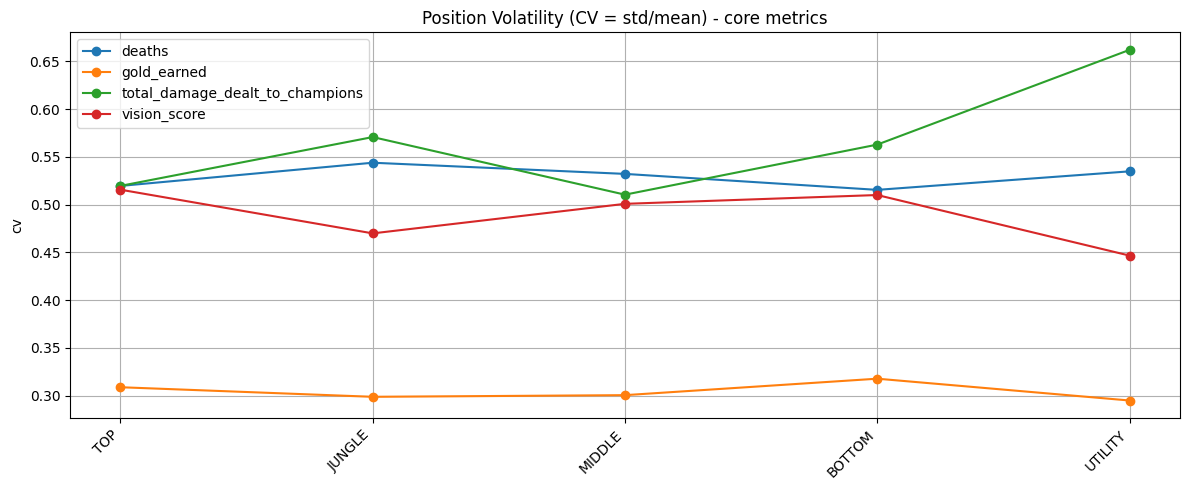

C:\Users\andor\AppData\Local\Temp\ipykernel_27916\1646129523.py:61: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = x.pivot_table(index=group_col, columns=metric_col, values=value_col, aggfunc="mean")


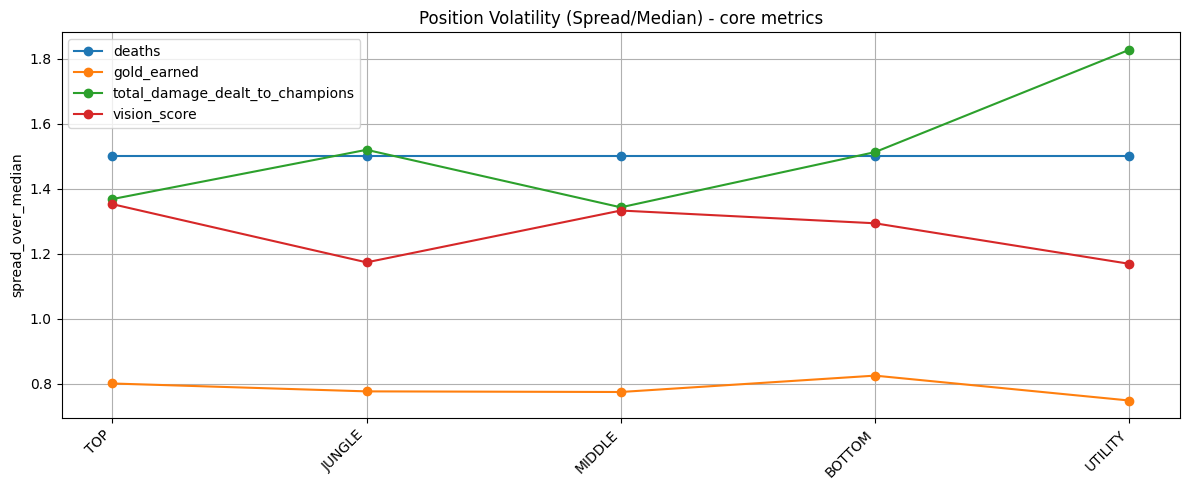

C:\Users\andor\AppData\Local\Temp\ipykernel_27916\1646129523.py:61: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = x.pivot_table(index=group_col, columns=metric_col, values=value_col, aggfunc="mean")


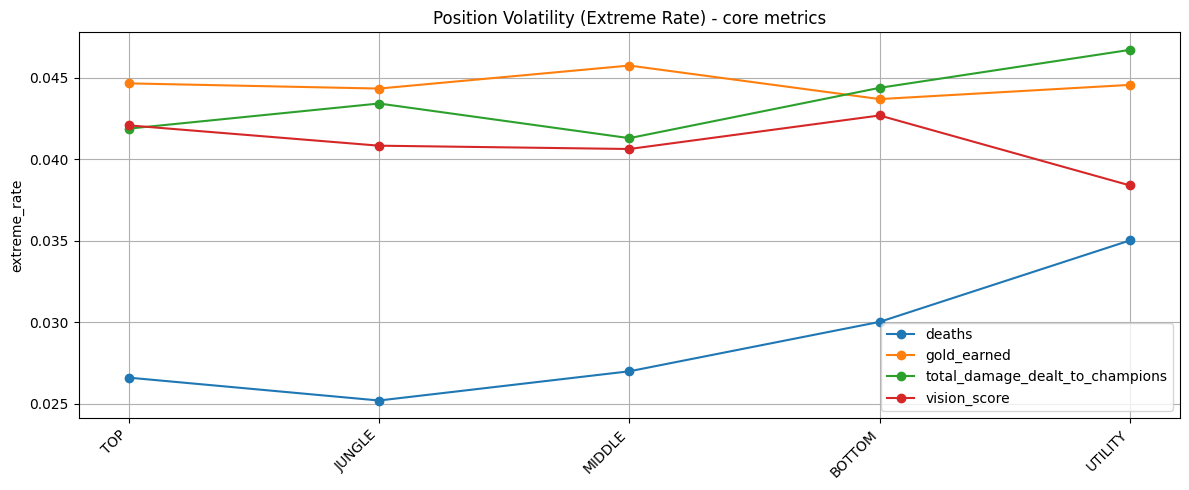

In [10]:
# 포지션별 표준편차 라인

POS_ORDER = ["TOP","JUNGLE","MIDDLE","BOTTOM","UTILITY"]
core_metrics = ["gold_earned", "total_damage_dealt_to_champions", "vision_score", "deaths"]

plot_grouped_metric(
    pos_risk_all[pos_risk_all["metric"].isin(core_metrics)],
    group_col="team_position",
    metric_col="metric",
    value_col="cv",
    title="Position Volatility (CV = std/mean) - core metrics",
    order=POS_ORDER
)

plot_grouped_metric(
    pos_risk_all[pos_risk_all["metric"].isin(core_metrics)],
    group_col="team_position",
    metric_col="metric",
    value_col="spread_over_median",
    title="Position Volatility (Spread/Median) - core metrics",
    order=POS_ORDER
)

plot_grouped_metric(
    pos_risk_all[pos_risk_all["metric"].isin(core_metrics)],
    group_col="team_position",
    metric_col="metric",
    value_col="extreme_rate",
    title="Position Volatility (Extreme Rate) - core metrics",
    order=POS_ORDER
)

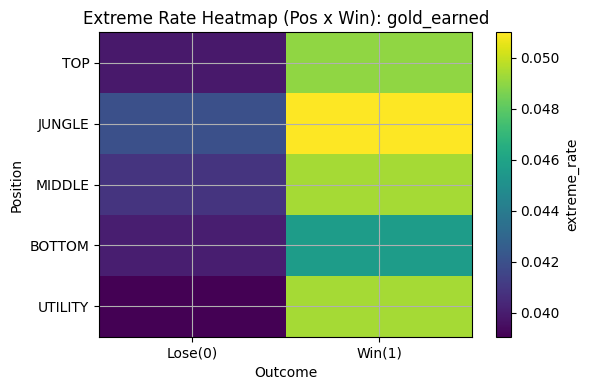

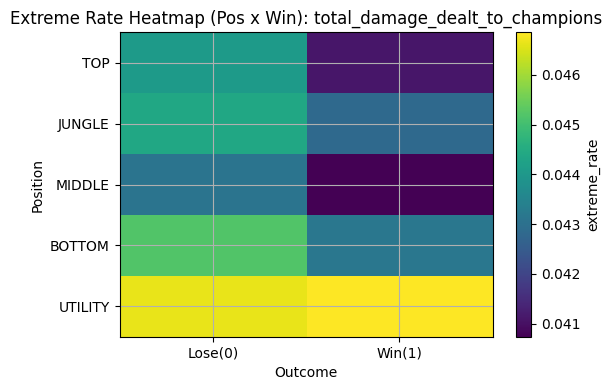

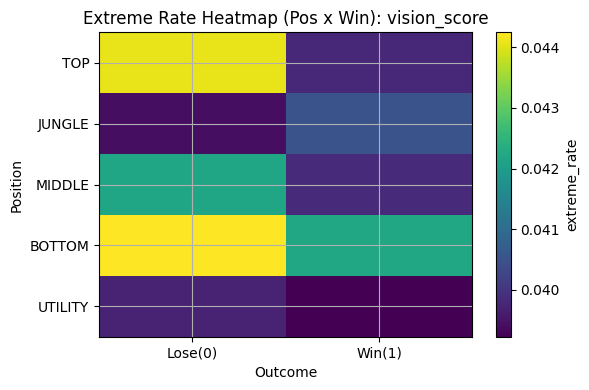

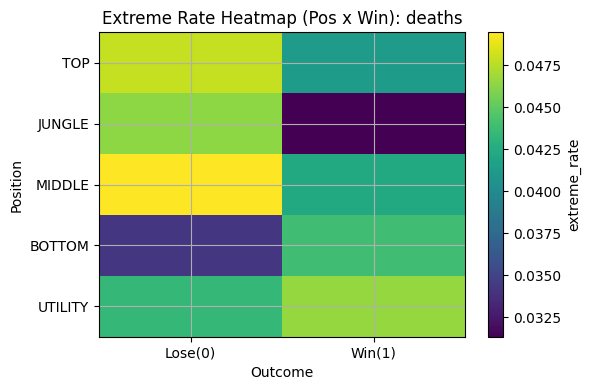

In [11]:
# 포지션 × 승/패 극단값 비율 heatmap

def plot_heatmap_pos_winloss(df, metric_name, value_col, title, pos_order=None):
    x = df[df["metric"].eq(metric_name)].copy()
    if pos_order is None:
        pos_order = sorted(x["team_position"].dropna().unique())
    # pivot: rows=pos, cols=win(0/1)
    p = x.pivot_table(index="team_position", columns="win", values=value_col, aggfunc="mean").reindex(pos_order)
    mat = p.values

    plt.figure(figsize=(6, 4))
    plt.imshow(mat, aspect="auto")
    plt.colorbar(label=value_col)
    plt.xticks([0,1], ["Lose(0)","Win(1)"])
    plt.yticks(range(len(pos_order)), pos_order)
    plt.xlabel("Outcome")
    plt.ylabel("Position")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for m in core_metrics:
    plot_heatmap_pos_winloss(pos_risk_pos_winloss, m, "extreme_rate", f"Extreme Rate Heatmap (Pos x Win): {m}", pos_order=POS_ORDER)

In [12]:
def topn(df, by_col, n=10, filter_metric=None):
    x = df.copy()
    if filter_metric is not None:
        x = x.loc[x["metric"].isin(filter_metric)].copy()
    return x.sort_values(by_col, ascending=False).head(n)

print("=== [TEAM] Top volatility by std (overall, by platform aggregated table) ===")
display(topn(team_risk_overall, "std", 15))

print("=== [TEAM] Top volatility by q90-10 spread ===")
display(topn(team_risk_overall, "q90_q10_spread", 15))

print("=== [TEAM] Top extreme_rate ===")
display(topn(team_risk_overall, "extreme_rate", 15))

print("\n=== [POS] Top volatility by std ===")
display(topn(pos_risk_all, "std", 15))

print("=== [POS] Top volatility by q90-10 spread ===")
display(topn(pos_risk_all, "q90_q10_spread", 15))

print("=== [POS] Top extreme_rate ===")
display(topn(pos_risk_all, "extreme_rate", 15))

=== [TEAM] Top volatility by std (overall, by platform aggregated table) ===


,group,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median
1,ALL_PLATFORMS,team_dmg_to_champions,159274,113890.966699,48082.533879,54816.6,175595.0,120778.4,0.038261,0.422180,1.102154
2,ALL_PLATFORMS,team_gold,159274,59937.103017,15968.105060,38696.0,79850.7,41154.7,0.051421,0.266414,0.682862
4,ALL_PLATFORMS,team_vision,159274,141.933574,53.856381,75.0,213.0,138.0,0.039617,0.379448,1.000000
0,ALL_PLATFORMS,team_deaths,159274,32.358703,13.130942,15.0,49.0,34.0,0.039247,0.405793,1.030303
3,ALL_PLATFORMS,team_kills,159274,32.246067,13.125759,15.0,49.0,34.0,0.034111,0.407050,1.062500


=== [TEAM] Top volatility by q90-10 spread ===


,group,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median
1,ALL_PLATFORMS,team_dmg_to_champions,159274,113890.966699,48082.533879,54816.6,175595.0,120778.4,0.038261,0.422180,1.102154
2,ALL_PLATFORMS,team_gold,159274,59937.103017,15968.105060,38696.0,79850.7,41154.7,0.051421,0.266414,0.682862
4,ALL_PLATFORMS,team_vision,159274,141.933574,53.856381,75.0,213.0,138.0,0.039617,0.379448,1.000000
0,ALL_PLATFORMS,team_deaths,159274,32.358703,13.130942,15.0,49.0,34.0,0.039247,0.405793,1.030303
3,ALL_PLATFORMS,team_kills,159274,32.246067,13.125759,15.0,49.0,34.0,0.034111,0.407050,1.062500


=== [TEAM] Top extreme_rate ===


...

,team_position,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
3,BOTTOM,total_damage_dealt_to_champions,159264,25783.063492,14512.324708,9994.0,44853.7,34859.7,0.044373,0.562863,1.513008,POS_ALL
18,TOP,total_damage_dealt_to_champions,159254,25602.572042,13304.560951,10849.0,42905.7,32056.7,0.041870,0.519657,1.368570,POS_ALL
13,MIDDLE,total_damage_dealt_to_champions,159252,25974.442393,13258.486462,11002.0,43191.9,32189.9,0.041287,0.510444,1.343177,POS_ALL
8,JUNGLE,total_damage_dealt_to_champions,159268,21462.775868,12249.674924,8072.0,37369.3,29297.3,0.043411,0.570740,1.520121,POS_ALL
23,UTILITY,total_damage_dealt_to_champions,159248,15072.051191,9977.798850,5452.0,28181.0,22729.0,0.046701,0.662007,1.827531,POS_ALL
1,BOTTOM,gold_earned,159264,13200.217262,4195.552331,7975.0,18652.0,10677.0,0.043682,0.317840,0.825499,POS_ALL
6,JUNGLE,gold_earned,159268,12755.048453,3812.171628,7926.0,17696.0,9770.0,0.044328,0.298876,0.777062,POS_ALL
16,TOP,gold_earned,159254,12315.771842,3804.370841,7491.0,17227.0,9736.0,0.044646,0.308902,0.801317,POS_ALL
11,MIDDLE,gold_earned,159252,12336.648990,3708.501556,7635.0,17074.0,9439.0,0.045739,0.300609,0.775150,POS_ALL
21,UTILITY,gold_earned,159248,9328.415597,2751.915042,5971.0,12817.3,6846.3,0.044553,0.295003,0.748966,POS_ALL


=== [POS] Top volatility by q90-10 spread ===


,team_position,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
3,BOTTOM,total_damage_dealt_to_champions,159264,25783.063492,14512.324708,9994.0,44853.7,34859.7,0.044373,0.562863,1.513008,POS_ALL
13,MIDDLE,total_damage_dealt_to_champions,159252,25974.442393,13258.486462,11002.0,43191.9,32189.9,0.041287,0.510444,1.343177,POS_ALL
18,TOP,total_damage_dealt_to_champions,159254,25602.572042,13304.560951,10849.0,42905.7,32056.7,0.041870,0.519657,1.368570,POS_ALL
8,JUNGLE,total_damage_dealt_to_champions,159268,21462.775868,12249.674924,8072.0,37369.3,29297.3,0.043411,0.570740,1.520121,POS_ALL
23,UTILITY,total_damage_dealt_to_champions,159248,15072.051191,9977.798850,5452.0,28181.0,22729.0,0.046701,0.662007,1.827531,POS_ALL
1,BOTTOM,gold_earned,159264,13200.217262,4195.552331,7975.0,18652.0,10677.0,0.043682,0.317840,0.825499,POS_ALL
6,JUNGLE,gold_earned,159268,12755.048453,3812.171628,7926.0,17696.0,9770.0,0.044328,0.298876,0.777062,POS_ALL
16,TOP,gold_earned,159254,12315.771842,3804.370841,7491.0,17227.0,9736.0,0.044646,0.308902,0.801317,POS_ALL
11,MIDDLE,gold_earned,159252,12336.648990,3708.501556,7635.0,17074.0,9439.0,0.045739,0.300609,0.775150,POS_ALL
21,UTILITY,gold_earned,159248,9328.415597,2751.915042,5971.0,12817.3,6846.3,0.044553,0.295003,0.748966,POS_ALL


=== [POS] Top extreme_rate ===


,team_position,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
2,BOTTOM,kills,159264,8.104098,5.443572,2.0,16.0,14.0,0.049490,0.671706,2.000000,POS_ALL
17,TOP,kills,159254,6.158960,4.357271,1.0,12.0,11.0,0.049481,0.707469,2.200000,POS_ALL
22,UTILITY,kills,159248,3.231501,3.138462,0.0,7.0,7.0,0.048968,0.971209,3.500000,POS_ALL
12,MIDDLE,kills,159252,7.214264,4.862098,2.0,14.0,12.0,0.048338,0.673956,2.000000,POS_ALL
23,UTILITY,total_damage_dealt_to_champions,159248,15072.051191,9977.798850,5452.0,28181.0,22729.0,0.046701,0.662007,1.827531,POS_ALL
11,MIDDLE,gold_earned,159252,12336.648990,3708.501556,7635.0,17074.0,9439.0,0.045739,0.300609,0.775150,POS_ALL
16,TOP,gold_earned,159254,12315.771842,3804.370841,7491.0,17227.0,9736.0,0.044646,0.308902,0.801317,POS_ALL
21,UTILITY,gold_earned,159248,9328.415597,2751.915042,5971.0,12817.3,6846.3,0.044553,0.295003,0.748966,POS_ALL
3,BOTTOM,total_damage_dealt_to_champions,159264,25783.063492,14512.324708,9994.0,44853.7,34859.7,0.044373,0.562863,1.513008,POS_ALL
6,JUNGLE,gold_earned,159268,12755.048453,3812.171628,7926.0,17696.0,9770.0,0.044328,0.298876,0.777062,POS_ALL


In [13]:
def take_top(df, group_cols, value_col, top_n=3):
    x = df.copy()
    x = x.sort_values(value_col, ascending=False).head(top_n)
    cols = group_cols + ["metric", value_col, "q90_q10_spread", "extreme_rate", "std"]
    cols = [c for c in cols if c in x.columns]
    return x[cols]

print_headline("NOTION SUMMARY (Draft)", [
    "팀 단위: 변동성/극단값이 큰 지표를 요약",
    "포지션 단위: 캐리 포지션 고분산 여부/서폿 가시성 구조 확인",
])

# 팀 전체 Top
print("\n[TEAM] Top Std")
display(take_top(team_risk_overall, ["platform"], "std", top_n=10))

print("\n[TEAM] Top 90-10 Spread")
display(take_top(team_risk_overall, ["platform"], "q90_q10_spread", top_n=10))

print("\n[TEAM] Top Extreme Rate")
display(take_top(team_risk_overall, ["platform"], "extreme_rate", top_n=10))

# 포지션 전체 Top (모든 metric이 많으면 core만)
print("\n[POS] Core metrics volatility table")
display(pos_risk_all[pos_risk_all["metric"].isin(["gold_earned","total_damage_dealt_to_champions","vision_score"])].sort_values(["team_position","metric"]))


NOTION SUMMARY (Draft)
 - 팀 단위: 변동성/극단값이 큰 지표를 요약
 - 포지션 단위: 캐리 포지션 고분산 여부/서폿 가시성 구조 확인

[TEAM] Top Std


,metric,std,q90_q10_spread,extreme_rate,std
1,team_dmg_to_champions,48082.533879,120778.4,0.038261,48082.533879
2,team_gold,15968.105060,41154.7,0.051421,15968.105060
4,team_vision,53.856381,138.0,0.039617,53.856381
0,team_deaths,13.130942,34.0,0.039247,13.130942
3,team_kills,13.125759,34.0,0.034111,13.125759



[TEAM] Top 90-10 Spread


,metric,q90_q10_spread,q90_q10_spread,extreme_rate,std
1,team_dmg_to_champions,120778.4,120778.4,0.038261,48082.533879
2,team_gold,41154.7,41154.7,0.051421,15968.105060
4,team_vision,138.0,138.0,0.039617,53.856381
0,team_deaths,34.0,34.0,0.039247,13.130942
3,team_kills,34.0,34.0,0.034111,13.125759



[TEAM] Top Extreme Rate


,metric,extreme_rate,q90_q10_spread,extreme_rate,std
2,team_gold,0.051421,41154.7,0.051421,15968.105060
4,team_vision,0.039617,138.0,0.039617,53.856381
0,team_deaths,0.039247,34.0,0.039247,13.130942
1,team_dmg_to_champions,0.038261,120778.4,0.038261,48082.533879
3,team_kills,0.034111,34.0,0.034111,13.125759



[POS] Core metrics volatility table


,team_position,metric,n,mean,std,q10,q90,q90_q10_spread,extreme_rate,cv,spread_over_median,label
1,BOTTOM,gold_earned,159264,13200.217262,4195.552331,7975.0,18652.0,10677.0,0.043682,0.317840,0.825499,POS_ALL
3,BOTTOM,total_damage_dealt_to_champions,159264,25783.063492,14512.324708,9994.0,44853.7,34859.7,0.044373,0.562863,1.513008,POS_ALL
4,BOTTOM,vision_score,159264,18.206877,9.286750,8.0,30.0,22.0,0.042678,0.510068,1.294118,POS_ALL
6,JUNGLE,gold_earned,159268,12755.048453,3812.171628,7926.0,17696.0,9770.0,0.044328,0.298876,0.777062,POS_ALL
8,JUNGLE,total_damage_dealt_to_champions,159268,21462.775868,12249.674924,8072.0,37369.3,29297.3,0.043411,0.570740,1.520121,POS_ALL
9,JUNGLE,vision_score,159268,24.647029,11.582455,12.0,39.0,27.0,0.040824,0.469933,1.173913,POS_ALL
11,MIDDLE,gold_earned,159252,12336.648990,3708.501556,7635.0,17074.0,9439.0,0.045739,0.300609,0.775150,POS_ALL
13,MIDDLE,total_damage_dealt_to_champions,159252,25974.442393,13258.486462,11002.0,43191.9,32189.9,0.041287,0.510444,1.343177,POS_ALL
14,MIDDLE,vision_score,159252,19.756537,9.895086,9.0,33.0,24.0,0.040621,0.500851,1.333333,POS_ALL
16,TOP,gold_earned,159254,12315.771842,3804.370841,7491.0,17227.0,9736.0,0.044646,0.308902,0.801317,POS_ALL
